In [1]:
import colormaps as cmaps
import matplotlib
print(cmaps.__version__)
print(matplotlib.__version__)
import numpy as np
from colormaps.utils import concat, show_cmaps_collection


0.4.2
3.10.8


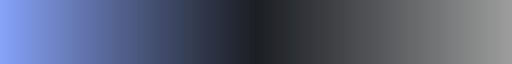

In [2]:
cmaps.bluegrey_dark

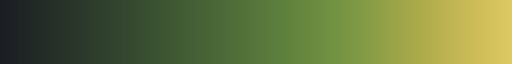

In [3]:
cmaps.earth_light

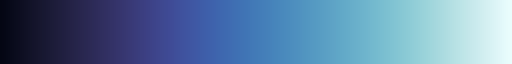

In [4]:
cmaps.ice

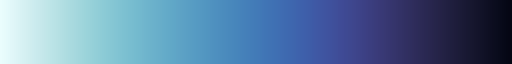

In [5]:
cmaps.ice_r

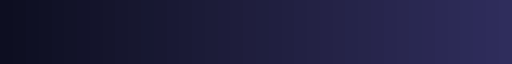

In [6]:
cmaps.ice[10:50]

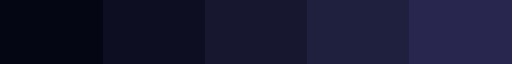

In [7]:
cmaps.ice[np.array([0, 10, 20, 30, 40])]

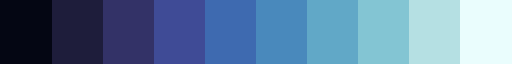

In [8]:
cmaps.ice.discrete(10)

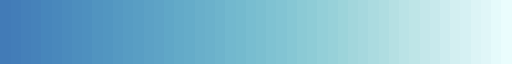

In [9]:
cmaps.ice.shift(0.5)

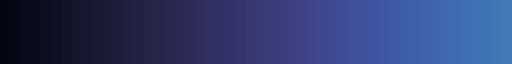

In [10]:
cmaps.ice.shift(-0.5)

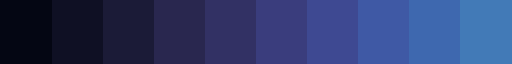

In [11]:
cmaps.ice.shift(-0.5).discrete(10)

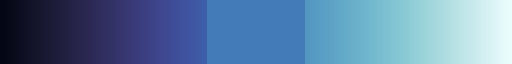

In [12]:
cmaps.ice.cut(0.2,)

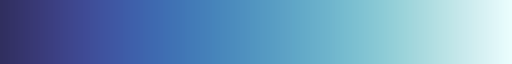

In [13]:
cmaps.ice.cut(0.2, 'left')

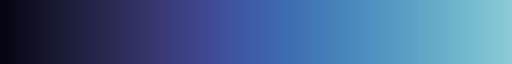

In [14]:
cmaps.ice.cut(0.2, 'right')

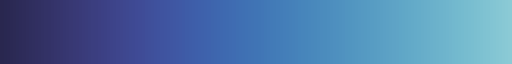

In [15]:
cmaps.ice.cut(0.2, 'right').cut(0.2, 'left')

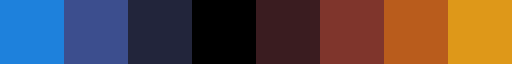

In [16]:
cmaps.iceburn.discrete(11).cut(0.25, 'left')

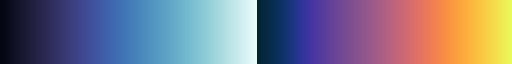

In [17]:
concat(["ice", "thermal"])

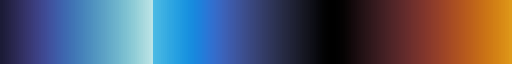

In [18]:
concat([cmaps.ice, cmaps.iceburn], ratios=[0.3, 0.7], trim=0.1)

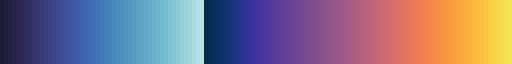

In [19]:
concat(
        ["ice", "thermal"],
        ratios=[0.4, 0.6],
        trim=[0.1, 0.05],
        discrete=128,
        name="my_concat"
    )

This may take some time... Please be patient.


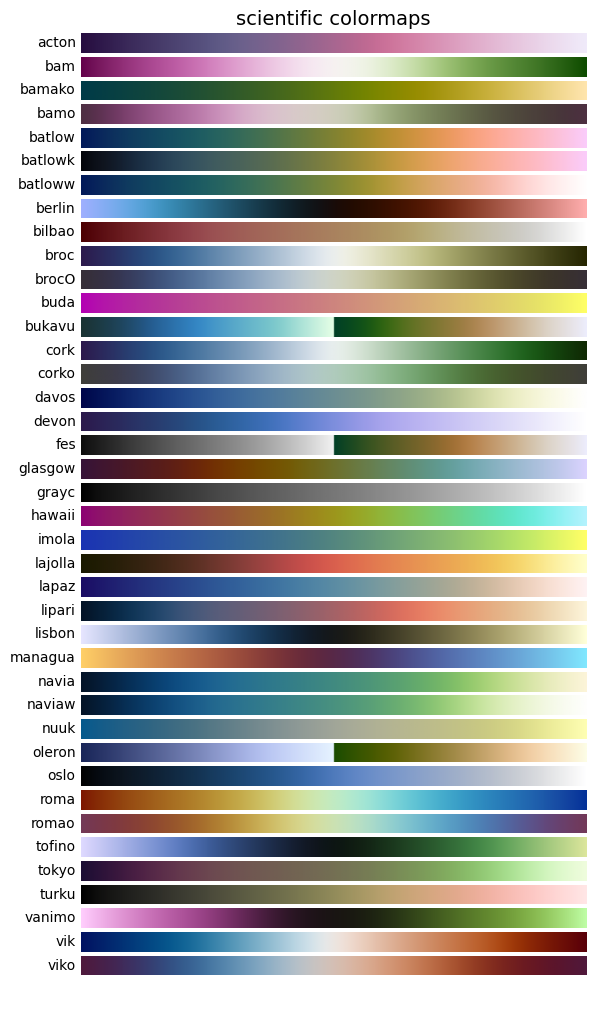

In [20]:
show_cmaps_collection('scientific')

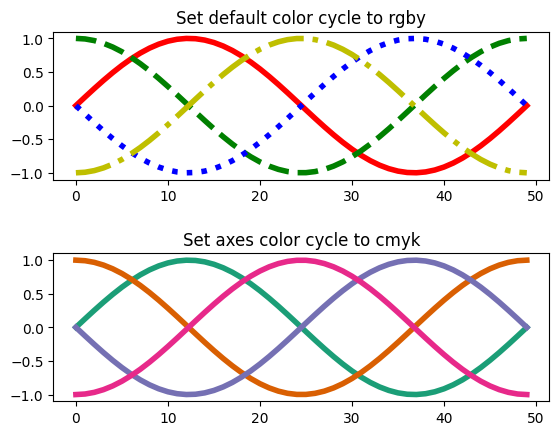

In [21]:
from cycler import cycler
import matplotlib.pyplot as plt
x = np.linspace(0, 2 * np.pi)
offsets = np.linspace(0, 2*np.pi, 4, endpoint=False)
# Create array with shifted-sine curve along each column
yy = np.transpose([np.sin(x + phi) for phi in offsets])

# 1. Setting prop cycle on default rc parameter
plt.rc('lines', linewidth=4)
plt.rc('axes', prop_cycle=(cycler('color', ['r', 'g', 'b', 'y']) +
                           cycler('linestyle', ['-', '--', ':', '-.'])))
fig, (ax0, ax1) = plt.subplots(nrows=2)
ax0.plot(yy)
ax0.set_title('Set default color cycle to rgby')

# 2. Define prop cycle for single set of axes
#ax1.set_prop_cycle(cycler('color', ['c', 'm', 'y', 'k']) +
#                   cycler('lw', [1, 2, 3, 4]))
ax1.set_prop_cycle(cycler('color', cmaps.dark2_8.colors))                   
ax1.plot(yy)
ax1.set_title('Set axes color cycle to cmyk')

# Tweak spacing between subplots to prevent labels from overlapping
fig.subplots_adjust(hspace=0.5)
plt.show()

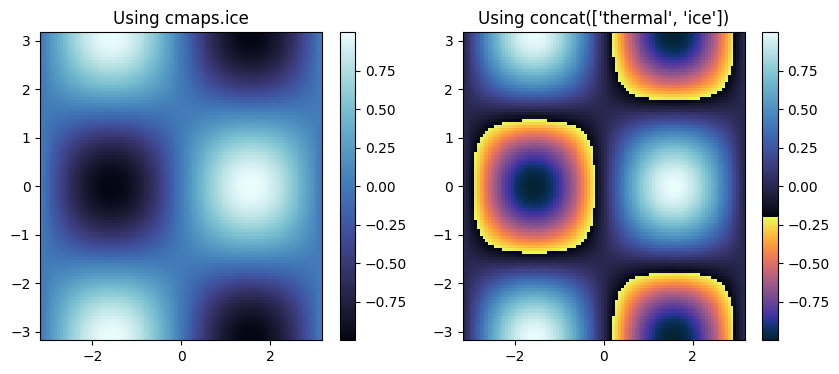

In [22]:
# Create sample data
X = np.linspace(-np.pi, np.pi, 100)
Y = np.linspace(-np.pi, np.pi, 100)
X, Y = np.meshgrid(X, Y)
Z = np.sin(X) * np.cos(Y)

# Plot with a colormap
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Using ice colormap
im1 = axes[0].pcolormesh(X, Y, Z, cmap=cmaps.ice, shading='auto')
axes[0].set_title("Using cmaps.ice")
plt.colorbar(im1, ax=axes[0])

# Using a custom concatenated colormap
custom_cmap = concat(["thermal", "ice"], ratios=[0.4, 0.6])
im2 = axes[1].pcolormesh(X, Y, Z, cmap=custom_cmap, shading='auto')
axes[1].set_title("Using concat(['thermal', 'ice'])")
plt.colorbar(im2, ax=axes[1])

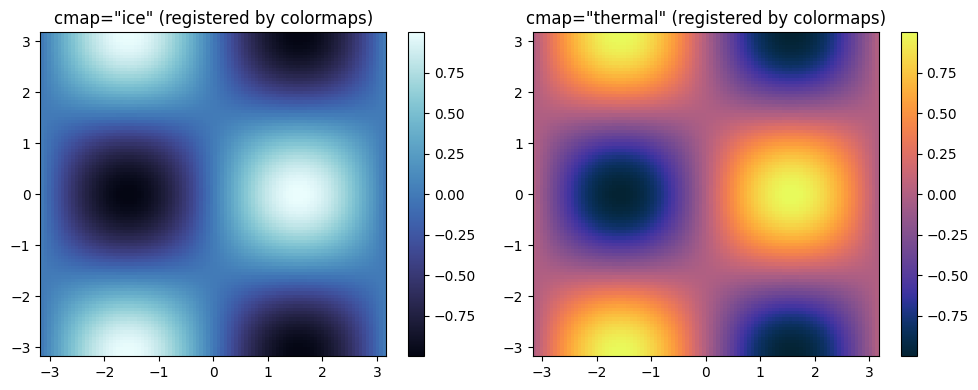

In [23]:
_ = cmaps.ice      # registers "ice" with matplotlib
_ = cmaps.thermal  # registers "thermal" with matplotlib

X = np.linspace(-np.pi, np.pi, 100)
Y = np.linspace(-np.pi, np.pi, 100)
X, Y = np.meshgrid(X, Y)
Z = np.sin(X) * np.cos(Y)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im1 = axes[0].pcolormesh(X, Y, Z, cmap="ice", shading='auto')
axes[0].set_title('cmap="ice" (registered by colormaps)')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(X, Y, Z, cmap="thermal", shading='auto')
axes[1].set_title('cmap="thermal" (registered by colormaps)')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()

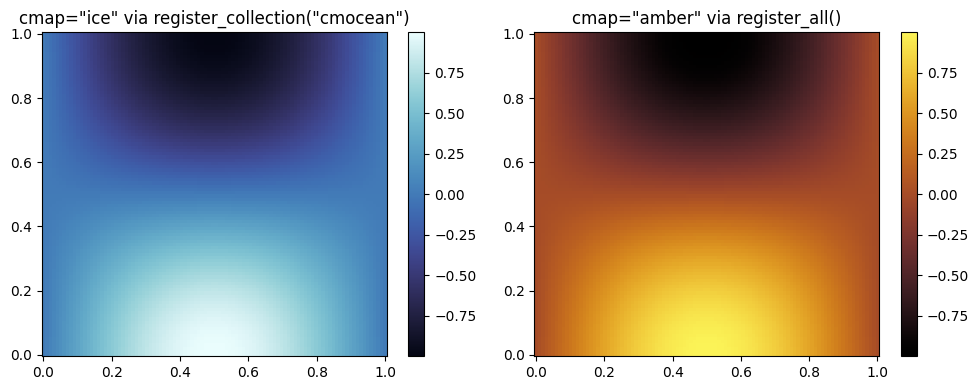

In [24]:
# Register a single collection up front
cmaps.register_collection('cmocean')

# Now use by string name without prior attribute access
X = np.linspace(0, 1, 100)
Y = np.linspace(0, 1, 100)
X, Y = np.meshgrid(X, Y)
Z = np.sin(np.pi * X) * np.cos(np.pi * Y)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im1 = axes[0].pcolormesh(X, Y, Z, cmap="ice", shading='auto')
axes[0].set_title('cmap="ice" via register_collection("cmocean")')
plt.colorbar(im1, ax=axes[0])

cmaps.register_all()

im2 = axes[1].pcolormesh(X, Y, Z, cmap="amber", shading='auto')
axes[1].set_title('cmap="amber" via register_all()')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()

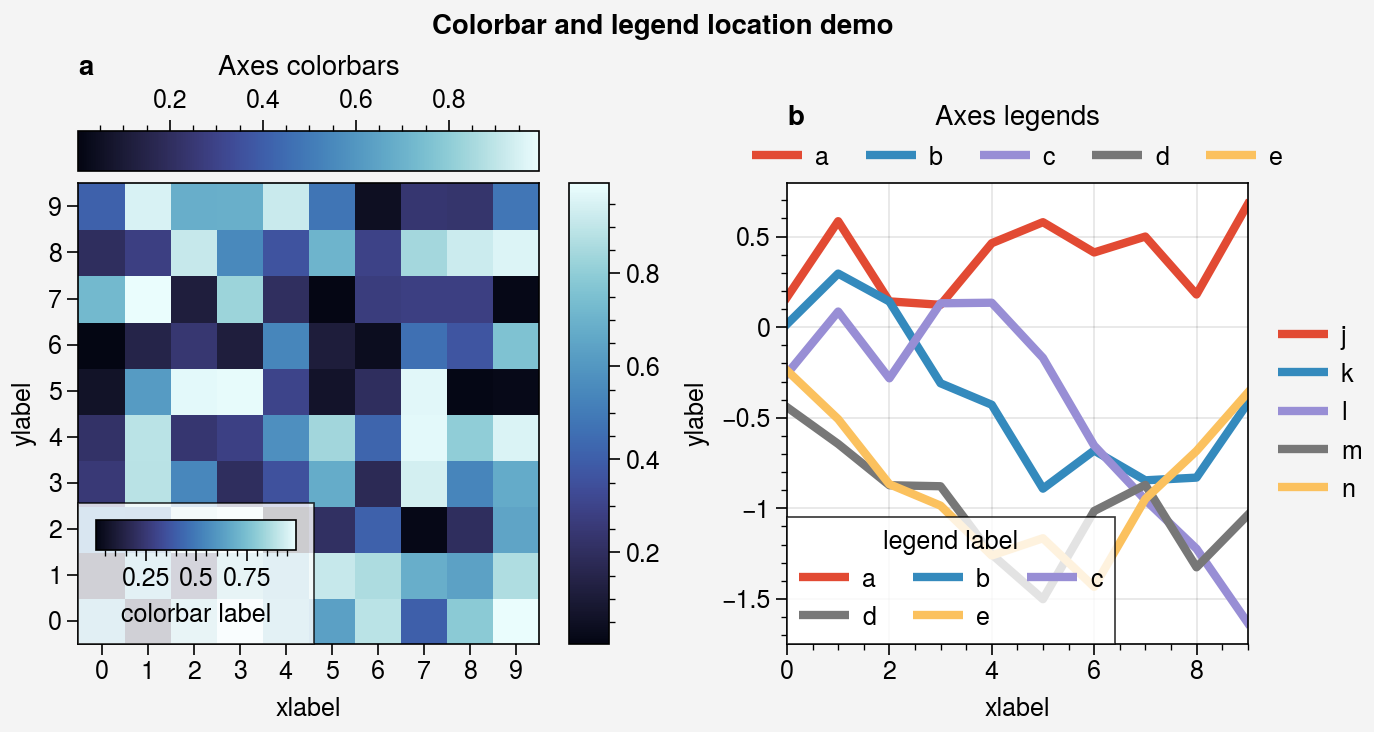

In [26]:
import numpy as np

import ultraplot as uplt

state = np.random.RandomState(51423)
fig = uplt.figure(share=False, refwidth=2.3)

# Colorbars
ax = fig.subplot(121, title="Axes colorbars")
data = state.rand(10, 10)
m = ax.heatmap(data, cmap="ice")
ax.colorbar(m, loc="r")
ax.colorbar(m, loc="t")  # title is automatically adjusted
ax.colorbar(m, loc="ll", label="colorbar label")  # inset colorbar demonstration

# Legends
ax = fig.subplot(122, title="Axes legends", titlepad="0em")
data = (state.rand(10, 5) - 0.5).cumsum(axis=0)
hs = ax.plot(data, lw=3, cycle="ggplot", labels=list("abcde"))
ax.legend(loc="ll", label="legend label")  # automatically infer handles and labels
ax.legend(hs, loc="t", ncols=5, frame=False)  # automatically infer labels from handles
ax.legend(hs, list("jklmn"), loc="r", ncols=1, frame=False)  # manually override labels
fig.format(
    abc=True,
    xlabel="xlabel",
    ylabel="ylabel",
    suptitle="Colorbar and legend location demo",
)